--- Початковий аналіз даних ---
Розмір набору даних: 606 рядків, 101 колонок
Типи ознак:
float64    100
int64        1
Name: count, dtype: int64
Пропущені значення: 0
Дублікати: 0

--- Співвідношення класів ---
P(y = 0) [Valley / Долина]: 0.5033 (305 об'єктів)
P(y = 1) [Hill / Пагорб]:   0.4967 (301 об'єктів)


C:\Users\Yaroslav\AppData\Local\Temp\ipykernel_9296\2032985363.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='viridis')


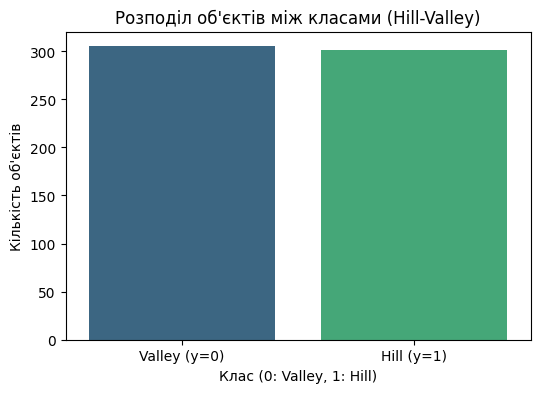

In [1]:
# ==============================================================================
# 1. ПОСТАНОВКА ЗАДАЧІ ТА ПОЧАТКОВИЙ АНАЛІЗ ДАНИХ (STAGE 1)
# ==============================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Створення папки для збереження графіків
os.makedirs('../figures', exist_ok=True)

# Завантаження набору даних Hill-Valley (без шуму)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/hill-valley/Hill_Valley_without_noise_Training.data"
df = pd.read_csv(url)

print("--- Початковий аналіз даних ---")
print(f"Розмір набору даних: {df.shape[0]} рядків, {df.shape[1]} колонок")
print(f"Типи ознак:\n{df.dtypes.value_counts()}")
print(f"Пропущені значення: {df.isnull().sum().sum()}")
print(f"Дублікати: {df.duplicated().sum()}")

# Обчислення часток класів
class_counts = df['class'].value_counts()
n_samples = len(df)
p_y0 = class_counts[0] / n_samples
p_y1 = class_counts[1] / n_samples

print("\n--- Співвідношення класів ---")
print(f"P(y = 0) [Valley / Долина]: {p_y0:.4f} ({class_counts[0]} об'єктів)")
print(f"P(y = 1) [Hill / Пагорб]:   {p_y1:.4f} ({class_counts[1]} об'єктів)")

# Візуалізація розподілу класів
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df, palette='viridis')
plt.title("Розподіл об'єктів між класами (Hill-Valley)")
plt.xlabel("Клас (0: Valley, 1: Hill)")
plt.ylabel("Кількість об'єктів")
plt.xticks([0, 1], ['Valley (y=0)', 'Hill (y=1)'])
plt.savefig('../figures/class_distribution.png', bbox_inches='tight')
plt.show()

In [7]:
# ==============================================================================
# ЕТАП 2. ФОРМУВАННЯ НАВЧАЛЬНОЇ ТА ТЕСТОВОЇ ВИБІРОК
# ==============================================================================
import pandas as pd
from sklearn.model_selection import train_test_split

# 2.1 Виділення матриці ознак X та цільової змінної y
X = df.drop(columns=['class'])
y = df['class']

# 2.2 Стратифікований поділ у співвідношенні 80% / 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 2.3 Перевірка співвідношення класів
def print_class_distribution(y_data, name):
    counts = y_data.value_counts()
    props = y_data.value_counts(normalize=True) * 100
    df_res = pd.DataFrame({
        'Кількість': counts,
        'Частка (%)': props.round(2)
    })
    print(f"--- {name} (Всього: {len(y_data)}) ---")
    print(df_res)
    print()

print_class_distribution(y, "Початковий набір даних")
print_class_distribution(y_train, "Навчальна вибірка (Train - 80%)")
print_class_distribution(y_test, "Тестова вибірка (Test - 20%)")

# Перевірка розмірностей
print(f"Розмірність X_train: {X_train.shape}")
print(f"Розмірність X_test:  {X_test.shape}")

# ПРИМІТКА ЩОДО ІЗОЛЯЦІЇ ДАНИХ:
# Тестова вибірка (X_test, y_test) є ізольованою. Вона НЕ використовується 
# для нормалізації (StandardScaler.fit), підбору моделей чи налаштування гіперпараметрів.

--- Початковий набір даних (Всього: 606) ---
       Кількість  Частка (%)
class                       
0            305       50.33
1            301       49.67

--- Навчальна вибірка (Train - 80%) (Всього: 484) ---
       Кількість  Частка (%)
class                       
0            244       50.41
1            240       49.59

--- Тестова вибірка (Test - 20%) (Всього: 122) ---
       Кількість  Частка (%)
class                       
1             61        50.0
0             61        50.0

Розмірність X_train: (484, 100)
Розмірність X_test:  (122, 100)


In [10]:
# ==============================================================================
# ЕТАП 3. ПОБУДОВА PREPROCESSING PIPELINE
# ==============================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd
import numpy as np


# Обґрунтування операцій Preprocessing:
- 1. Пропущені значення: відсутні (додаткова обробка не потрібна).
- 2. Категоріальні ознаки: відсутні (всі 100 ознак числові float64).
- 3. Масштабування: застосовується StandardScaler для приведення ознак до нульового середнього та одиничної дисперсії (Z-score normalization).

# Запобігання Data Leakage:
 Всі перетворення (StandardScaler) огортаються в `Pipeline`. Це гарантує, що `fit` масштабувальника виконується ВИКЛЮЧНО на навчальних даних (або навчальних фолдах під час крос-валідації), а тестові дані лише трансформуються (`transform`)

In [9]:
# ==============================================================================
# ЕТАП 4. ПОБУДОВА ТА ОЦІНКА BASELINE
# ==============================================================================

# 4.1 Створення пайплайну для Baseline (найпростіший класифікатор)
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('baseline', DummyClassifier(strategy="most_frequent"))
])

# 4.2 Стратифікована 5-fold крос-валідація
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Оцінювання baseline строго на навчальних даних X_train, y_train
cv_results_baseline = cross_validate(
    baseline_pipeline, 
    X_train, 
    y_train, 
    cv=cv, 
    scoring=scoring_metrics
)

# 4.3 Формування підсумкових метрик baseline
baseline_summary = {
    'Accuracy':  cv_results_baseline['test_accuracy'].mean(),
    'Precision': cv_results_baseline['test_precision'].mean(),
    'Recall':    cv_results_baseline['test_recall'].mean(),
    'F1-score':  cv_results_baseline['test_f1'].mean(),
    'ROC-AUC':   cv_results_baseline['test_roc_auc'].mean()
}

df_baseline_results = pd.DataFrame([baseline_summary], index=['Baseline (DummyClassifier)'])

print("--- Результати 5-Fold Stratified Cross-Validation для Baseline ---")
print(df_baseline_results.round(4).to_string())

C:\Users\Yaroslav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Yaroslav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Yaroslav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classificat

--- Результати 5-Fold Stratified Cross-Validation для Baseline ---
                            Accuracy  Precision  Recall  F1-score  ROC-AUC
Baseline (DummyClassifier)    0.5041        0.0     0.0       0.0      0.5


C:\Users\Yaroslav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [11]:
# ==============================================================================
# ЕТАП 5. ПОБУДОВА ТА ОЦІНКА МОДЕЛЕЙ КЛАСИФІКАЦІЇ
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# 5.1 Створення Preprocessing Pipelines для моделей
# Масштабування StandardScaler включено всередину Pipeline для кожної моделі
pipelines = {
    'Baseline (Dummy)': baseline_pipeline,  # Збережено з Етапу 4
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'GaussianNB': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GaussianNB())
    ])
}

# 5.2 Проведення 5-fold stratified cross-validation за однаковою схемою
results_list = []

for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe, 
        X_train, 
        y_train, 
        cv=cv, 
        scoring=scoring_metrics
    )
    
    results_list.append({
        'Модель': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean()
    })

# 5.3 Формування підсумкової порівняльної таблиці
df_cv_results = pd.DataFrame(results_list)

print("--- ТАБЛ. 4. Результати cross-validation ---")
print(df_cv_results.round(4).to_string(index=False))

C:\Users\Yaroslav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Yaroslav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Yaroslav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classificat

--- ТАБЛ. 4. Результати cross-validation ---
             Модель  Accuracy  Precision  Recall     F1  ROC-AUC
   Baseline (Dummy)    0.5041     0.0000  0.0000 0.0000   0.5000
Logistic Regression    0.6695     0.6602  0.8750 0.7127   0.9336
         GaussianNB    0.5083     0.5017  0.8792 0.6385   0.5192


In [12]:
# ==============================================================================
# ЕТАП 6. ВИБІР МОДЕЛІ ТА ОЦІНЮВАННЯ НА TEST SET
# ==============================================================================

# 6.1 Обґрунтування вибору моделі:
# Модель Logistic Regression обрано для подальшого аналізу, оскільки вона показала 
# найкращі та найбільш стабільні результати за всіма метриками (Accuracy, Precision, 
# Recall, F1-score, ROC-AUC) на етапі 5-fold cross-validation, суттєво перевершивши Baseline.

# 6.2 Навчання вибраної моделі на всій навчальній вибірці (X_train, y_train)
best_model = pipelines['Logistic Regression']
best_model.fit(X_train, y_train)

# 6.3 Одноразове виконане прогнозування на тестовій вибірці (test set)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# 6.4 Відображення перших 10 результатів передбачень для перевірки
df_preds_preview = pd.DataFrame({
    'True Label (y_test)': y_test.values,
    'Predicted Class (y_pred)': y_pred,
    'Predicted Proba (y_proba)': y_proba.round(4)
})

print("--- Перші 10 передбачень вибраної моделі на тестовій вибірці ---")
print(df_preds_preview.head(10).to_string())

--- Перші 10 передбачень вибраної моделі на тестовій вибірці ---
   True Label (y_test)  Predicted Class (y_pred)  Predicted Proba (y_proba)
0                    1                         1                     0.5073
1                    1                         1                     0.5073
2                    0                         1                     0.5058
3                    1                         1                     0.5136
4                    1                         1                     0.5074
5                    0                         1                     0.5070
6                    1                         1                     0.5073
7                    1                         1                     0.5072
8                    1                         1                     0.5133
9                    0                         1                     0.5071


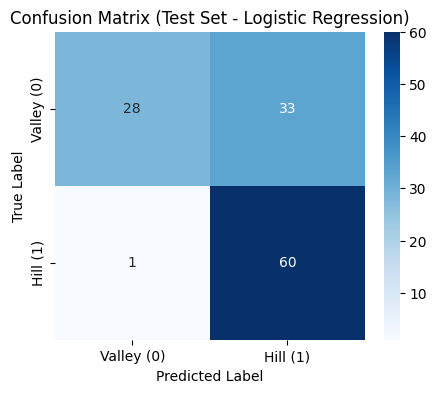

--- Значення елементів Confusion Matrix ---
True Negatives  (TN): 28 (Дійсно Долина, спрогнозовано Долину)
False Positives (FP): 33 (Дійсно Долина, помилково спрогнозовано Пагорб)
False Negatives (FN): 1 (Дійсно Пагорб, помилково спрогнозовано Долину)
True Positives  (TP): 60 (Дійсно Пагорб, спрогнозовано Пагорб)


In [13]:
# ==============================================================================
# ЕТАП 7. ПОБУДОВА ТА АНАЛІЗ CONFUSION MATRIX
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score
)

# 7.1 Побудова Confusion Matrix для test set
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Візуалізація Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Valley (0)', 'Hill (1)'],
            yticklabels=['Valley (0)', 'Hill (1)'])
plt.title("Confusion Matrix (Test Set - Logistic Regression)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig('../figures/confusion_matrix.png', bbox_inches='tight')
plt.show()

print("--- Значення елементів Confusion Matrix ---")
print(f"True Negatives  (TN): {tn} (Дійсно Долина, спрогнозовано Долину)")
print(f"False Positives (FP): {fp} (Дійсно Долина, помилково спрогнозовано Пагорб)")
print(f"False Negatives (FN): {fn} (Дійсно Пагорб, помилково спрогнозовано Долину)")
print(f"True Positives  (TP): {tp} (Дійсно Пагорб, спрогнозовано Пагорб)")

In [14]:
# ==============================================================================
# ЕТАП 8. ОЦІНЮВАННЯ МОДЕЛІ НА TEST SET ТА ПОРІВНЯННЯ
# ==============================================================================

# 8.1 Обчислення метрик на тестовій вибірці
test_metrics = {
    'Модель / Вибірка': 'Logistic Regression (Test Set)',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1': f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}

# 8.2 Створення порівняльної таблиці (Baseline CV vs Model CV vs Model Test)
comparison_list = [
    {
        'Модель / Вибірка': 'Baseline (CV)',
        'Accuracy': cv_results_baseline['test_accuracy'].mean(),
        'Precision': cv_results_baseline['test_precision'].mean(),
        'Recall': cv_results_baseline['test_recall'].mean(),
        'F1': cv_results_baseline['test_f1'].mean(),
        'ROC-AUC': cv_results_baseline['test_roc_auc'].mean()
    },
    {
        'Модель / Вибірка': 'Logistic Regression (CV)',
        'Accuracy': df_cv_results.loc[df_cv_results['Модель'] == 'Logistic Regression', 'Accuracy'].values[0],
        'Precision': df_cv_results.loc[df_cv_results['Модель'] == 'Logistic Regression', 'Precision'].values[0],
        'Recall': df_cv_results.loc[df_cv_results['Модель'] == 'Logistic Regression', 'Recall'].values[0],
        'F1': df_cv_results.loc[df_cv_results['Модель'] == 'Logistic Regression', 'F1'].values[0],
        'ROC-AUC': df_cv_results.loc[df_cv_results['Модель'] == 'Logistic Regression', 'ROC-AUC'].values[0]
    },
    test_metrics
]

df_final_comparison = pd.DataFrame(comparison_list)
print("\n--- Порівняльна таблиця результатів ---")
print(df_final_comparison.round(4).to_string(index=False))


--- Порівняльна таблиця результатів ---
              Модель / Вибірка  Accuracy  Precision  Recall     F1  ROC-AUC
                 Baseline (CV)    0.5041     0.0000  0.0000 0.0000   0.5000
      Logistic Regression (CV)    0.6695     0.6602  0.8750 0.7127   0.9336
Logistic Regression (Test Set)    0.7213     0.6452  0.9836 0.7792   0.9610


--- ТАБЛ. 5. Помилково класифіковані об'єкти (Перші 10) ---
 Index  Actual  Predicted  Probability Error type  d (|p - 0.5|)
    41       0          1       0.5058         FP         0.0058
   395       0          1       0.5070         FP         0.0070
    99       0          1       0.5071         FP         0.0071
   203       0          1       0.5072         FP         0.0072
   265       0          1       0.5052         FP         0.0052
    71       0          1       0.5071         FP         0.0071
   119       0          1       0.5070         FP         0.0070
   495       0          1       0.5063         FP         0.0063
   544       0          1       0.5071         FP         0.0071
   109       0          1       0.5070         FP         0.0070

Кількість граничних помилок (|p - 0.5| < 0.1): 34
Кількість впевнених помилок   (|p - 0.5| > 0.3): 0


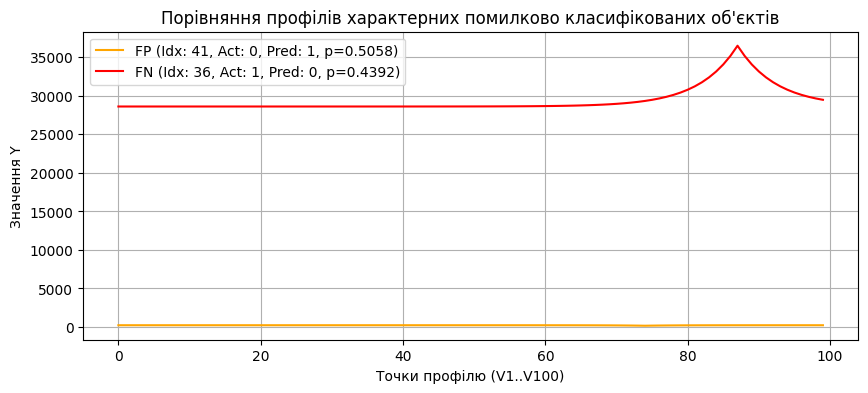

In [15]:
# ==============================================================================
# ЕТАП 9. АНАЛІЗ ПОМИЛКОВО КЛАСИФІКОВАНИХ ОБ'ЄКТІВ
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 9.1 Формування таблиці помилок з розрахунком d = |p - 0.5|
test_indices = y_test.index
errors_mask = y_test.values != y_pred

df_errors = pd.DataFrame({
    'Index': test_indices[errors_mask],
    'Actual': y_test.values[errors_mask],
    'Predicted': y_pred[errors_mask],
    'Probability': y_proba[errors_mask]
})

df_errors['Error type'] = np.where(
    (df_errors['Actual'] == 0) & (df_errors['Predicted'] == 1), 'FP', 'FN'
)
df_errors['d (|p - 0.5|)'] = (df_errors['Probability'] - 0.5).abs().round(4)
df_errors['Probability'] = df_errors['Probability'].round(4)

print("--- ТАБЛ. 5. Помилково класифіковані об'єкти (Перші 10) ---")
print(df_errors.head(10).to_string(index=False))

# 9.2 Аналіз впевненості моделі в помилках
borderline_errors = df_errors[df_errors['d (|p - 0.5|)'] < 0.1]
confident_errors = df_errors[df_errors['d (|p - 0.5|)'] > 0.3]

print(f"\nКількість граничних помилок (|p - 0.5| < 0.1): {len(borderline_errors)}")
print(f"Кількість впевнених помилок   (|p - 0.5| > 0.3): {len(confident_errors)}")

# 9.3 Візуалізація профілів для характерних FP та FN
plt.figure(figsize=(10, 4))

if not df_errors[df_errors['Error type'] == 'FP'].empty:
    fp_row = df_errors[df_errors['Error type'] == 'FP'].iloc[0]
    plt.plot(X_test.loc[fp_row['Index']].values, 
             label=f"FP (Idx: {fp_row['Index']}, Act: 0, Pred: 1, p={fp_row['Probability']})", color='orange')

if not df_errors[df_errors['Error type'] == 'FN'].empty:
    fn_row = df_errors[df_errors['Error type'] == 'FN'].iloc[0]
    plt.plot(X_test.loc[fn_row['Index']].values, 
             label=f"FN (Idx: {fn_row['Index']}, Act: 1, Pred: 0, p={fn_row['Probability']})", color='red')

plt.title("Порівняння профілів характерних помилково класифікованих об'єктів")
plt.xlabel("Точки профілю (V1..V100)")
plt.ylabel("Значення Y")
plt.legend()
plt.grid(True)
plt.savefig('../figures/error_profiles.png', bbox_inches='tight')
plt.show()